**LAB EXPERIMENT 06**\
**Implementation of Ensemble Techniques (Bagging, Boosting, Random Forest, Stacking) and Handling Class Imbalance (SMOTE)**

NAME: Priya Dharshini R\
ROLL NO.: 24BAD092

**SCENARIO 1**– (Bagging)

**Problem Statement:**\
Predict whether a patient has diabetes.

**Dataset:** \
Diabetes Dataset

**Target Variable:**\
Outcome (0 = No Diabetes, 1 = Diabetes)

**Input Features:**\
Glucose, BMI, Age, Blood Pressure, etc.

**IN-LAB TASKS**\
•	Load dataset\
•	Train Decision Tree\
•	Apply BaggingClassifier\
•	Compare accuracy

**Visualization**\
•	Accuracy comparison bar graph\
•	Confusion matrix



Name     : Priya Dharshini R
Roll No  : 24BAD092
Scenario : Bagging (Diabetes Prediction)
===== Model Accuracy =====
Decision Tree Accuracy : 1.0000
Bagging Accuracy       : 1.0000


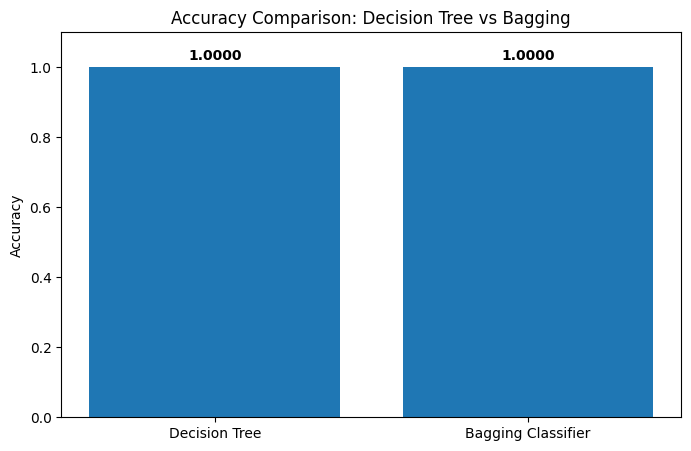

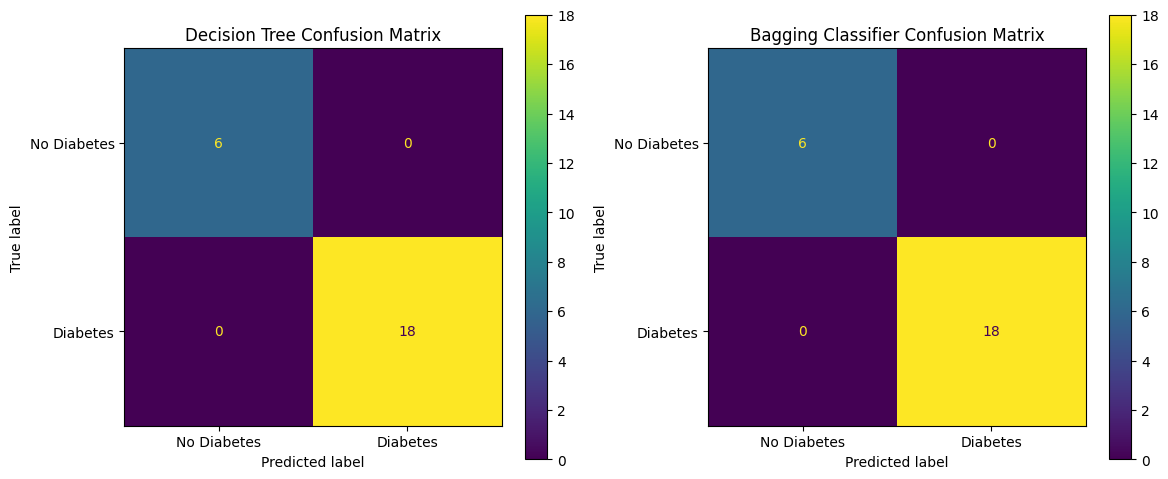

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# PRINT STUDENT DETAILS
print("Name     : Priya Dharshini R")
print("Roll No  : 24BAD092")
print("Scenario : Bagging (Diabetes Prediction)")

# Load dataset
df = pd.read_csv(r"/content/sample_data/diabetes_bagging.csv")

# Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Decision Tree Model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

# Bagging Classifier
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

bag.fit(X_train, y_train)

bag_pred = bag.predict(X_test)
bag_acc = accuracy_score(y_test, bag_pred)

# PRINT RESULTS
print("===== Model Accuracy =====")
print(f"Decision Tree Accuracy : {dt_acc:.4f}")
print(f"Bagging Accuracy       : {bag_acc:.4f}")

# Accuracy Comparison Graph
plt.figure(figsize=(8, 5))

models = ['Decision Tree', 'Bagging Classifier']
accuracies = [dt_acc, bag_acc]

plt.bar(models, accuracies)
plt.title('Accuracy Comparison: Decision Tree vs Bagging')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree CM
cm_dt = confusion_matrix(y_test, dt_pred)
ConfusionMatrixDisplay(cm_dt, display_labels=['No Diabetes', 'Diabetes']).plot(ax=axes[0])
axes[0].set_title('Decision Tree Confusion Matrix')

# Bagging CM
cm_bag = confusion_matrix(y_test, bag_pred)
ConfusionMatrixDisplay(cm_bag, display_labels=['No Diabetes', 'Diabetes']).plot(ax=axes[1])
axes[1].set_title('Bagging Classifier Confusion Matrix')

plt.tight_layout()
plt.show()

**SCENARIO 2**– (Boosting-AdaBoost, Gradient Boosting)

**Problem Statement:** \
Predict whether a customer will churn.

**Dataset:** \
Telco Customer Churn Dataset

**Target Variable:**\
Churn (Yes/No)

**Input Features:** \
Tenure, Monthly Charges, Contract Type

**IN-LAB TASKS**\
•	Train AdaBoost\
•	Train Gradient Boosting\
•	Compare performance

**Visualization**\
•	ROC Curve\
•	Feature Importance plot



Name     : Priya Dharshini R
Roll No  : 24BAD092
Scenario : Boosting (Customer Churn Prediction)
Model Accuracy Results
AdaBoost Accuracy           : 1.0000
Gradient Boosting Accuracy  : 1.0000


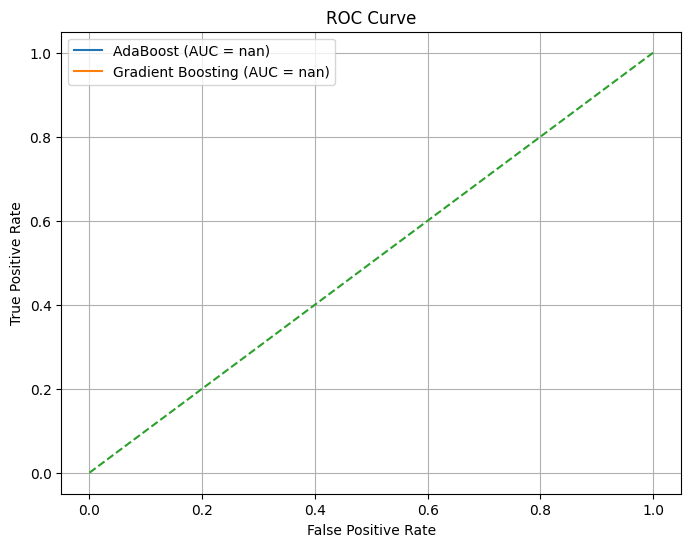

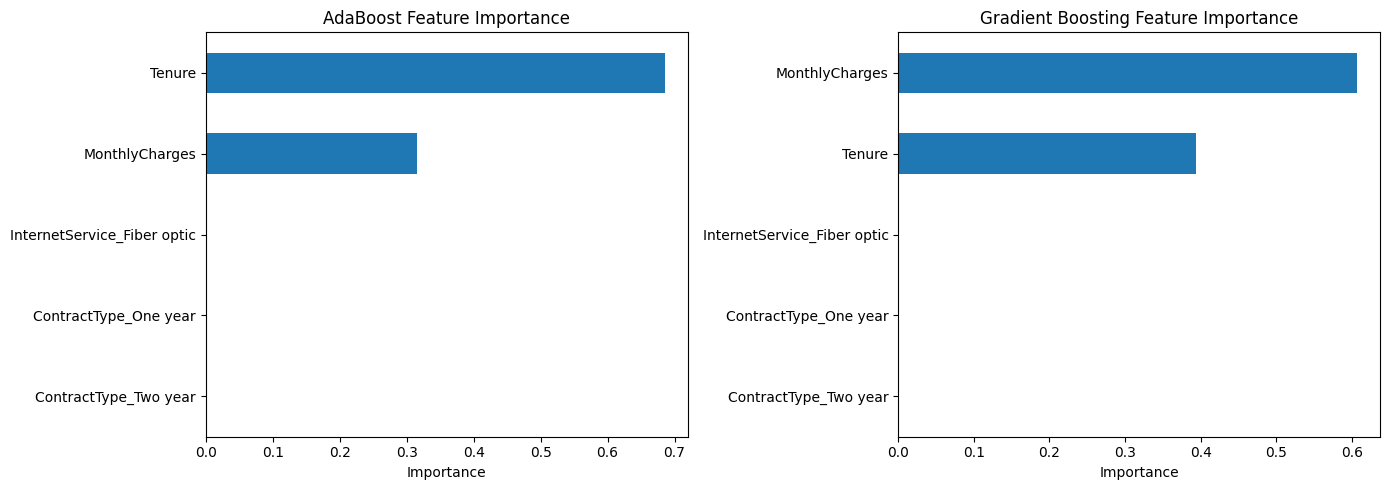

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

# Print student details
print("Name     : Priya Dharshini R")
print("Roll No  : 24BAD092")
print("Scenario : Boosting (Customer Churn Prediction)")

# Load dataset
df = pd.read_csv(r"/content/sample_data/churn_boosting.csv")

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convert categorical data
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# AdaBoost Model
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)
ada_prob = ada.predict_proba(X_test)[:, 1]
ada_acc = accuracy_score(y_test, ada_pred)

# Gradient Boosting Model
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
gb_acc = accuracy_score(y_test, gb_pred)

# Print accuracy
print("Model Accuracy Results")
print(f"AdaBoost Accuracy           : {ada_acc:.4f}")
print(f"Gradient Boosting Accuracy  : {gb_acc:.4f}")

# ROC Curve
fpr_ada, tpr_ada, _ = roc_curve(y_test, ada_prob)
roc_auc_ada = auc(fpr_ada, tpr_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
roc_auc_gb = auc(fpr_gb, tpr_gb)
plt.figure(figsize=(8, 6))

plt.plot(fpr_ada, tpr_ada, label=f'AdaBoost (AUC = {roc_auc_ada:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC = {roc_auc_gb:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()

plt.show()
# Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ada_importances = pd.Series(ada.feature_importances_, index=X.columns).sort_values()
ada_importances.plot(kind='barh', ax=axes[0])
axes[0].set_title('AdaBoost Feature Importance')
axes[0].set_xlabel('Importance')

gb_importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values()
gb_importances.plot(kind='barh', ax=axes[1])
axes[1].set_title('Gradient Boosting Feature Importance')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

**SCENARIO 3 – Random Forest**

**Problem Statement:** \
Predict whether a person earns >50K salary.

**Dataset:** \
Adult Income Dataset

**Target Variable:**\
Income (>50K or <=50K)

**Input Features:** \
Age, Education, Occupation, Hours-per-week

**IN-LAB TASKS**\
•	Train Random Forest\
•	Tune number of trees\
•	Evaluate model

**Visualization**\
•	Feature Importance\
•	Accuracy vs Number of Trees graph


Name     : Priya Dharshini R
Roll No  : 24BAD092
Model    : Random Forest (Income Prediction)
Best Number of Trees : 10
Best Accuracy        : 1.0000


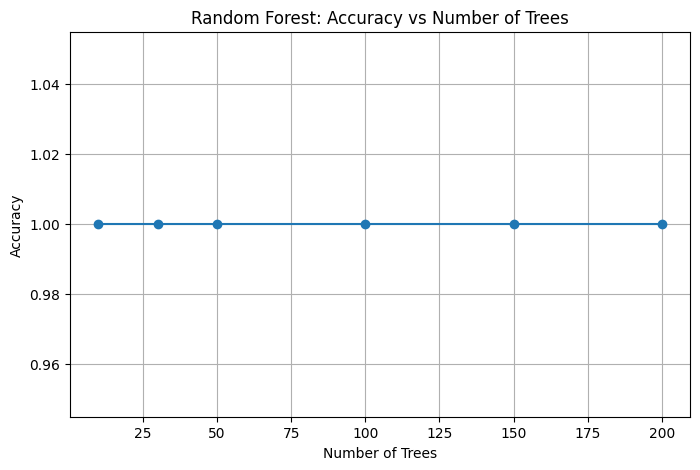

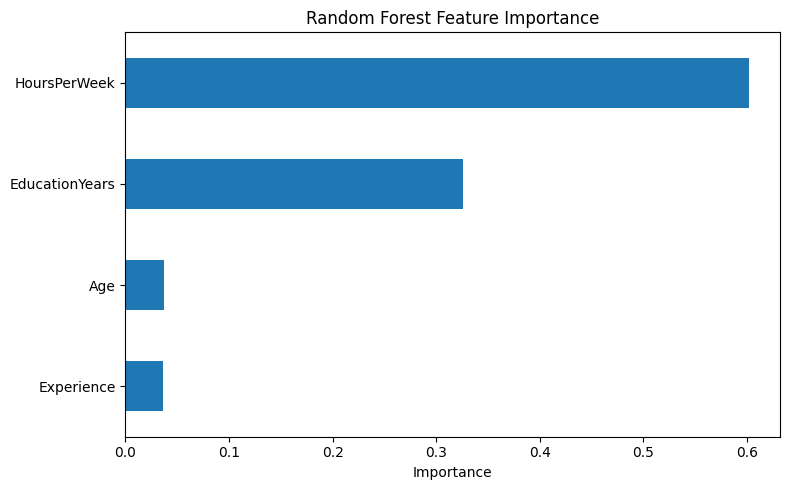

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Print student details
print("Name     : Priya Dharshini R")
print("Roll No  : 24BAD092")
print("Model    : Random Forest (Income Prediction)")

# Load dataset
df = pd.read_csv(r"/content/sample_data/income_random_forest.csv")

# Split data
X = df.drop('Income', axis=1)
y = df['Income']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Different number of trees
n_estimators_list = [10, 30, 50, 100, 150, 200]
accuracies = []

best_acc = 0
best_n = 0
best_model = None

# Train models
for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    pred = rf.predict(X_test)
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)

    if acc > best_acc:
        best_acc = acc
        best_n = n
        best_model = rf

# Print results
print(f"Best Number of Trees : {best_n}")
print(f"Best Accuracy        : {best_acc:.4f}")

# Accuracy vs Trees graph
plt.figure(figsize=(8, 5))
plt.plot(n_estimators_list, accuracies, marker='o', linestyle='-')
plt.title('Random Forest: Accuracy vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.grid()
plt.show()

# Feature importance
plt.figure(figsize=(8, 5))
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()

importances.plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

**SCENARIO 4 – Stacking**

**Problem Statement:** \
Predict heart disease presence.

**Dataset:**\
Heart Disease Dataset

**Target Variable:** \
Presence of Heart Disease (0/1)

**Input Features:**\
Cholesterol, Max Heart Rate, Age

**IN-LAB TASKS**\
•	Train base models (Logistic Regression, SVM, Decision Tree)\
•	Combine using StackingClassifier\
•	Compare with individual models

**Visualization**\
•	Model comparison bar chart



Name     : Priya Dharshini R
Roll No  : 24BAD092
Scenario : Stacking (Heart Disease Prediction)
Model Accuracy Results
Logistic Regression Accuracy : 0.8333
SVM Accuracy                : 0.8333
Decision Tree Accuracy      : 0.9583
Stacking Classifier Accuracy: 0.9583


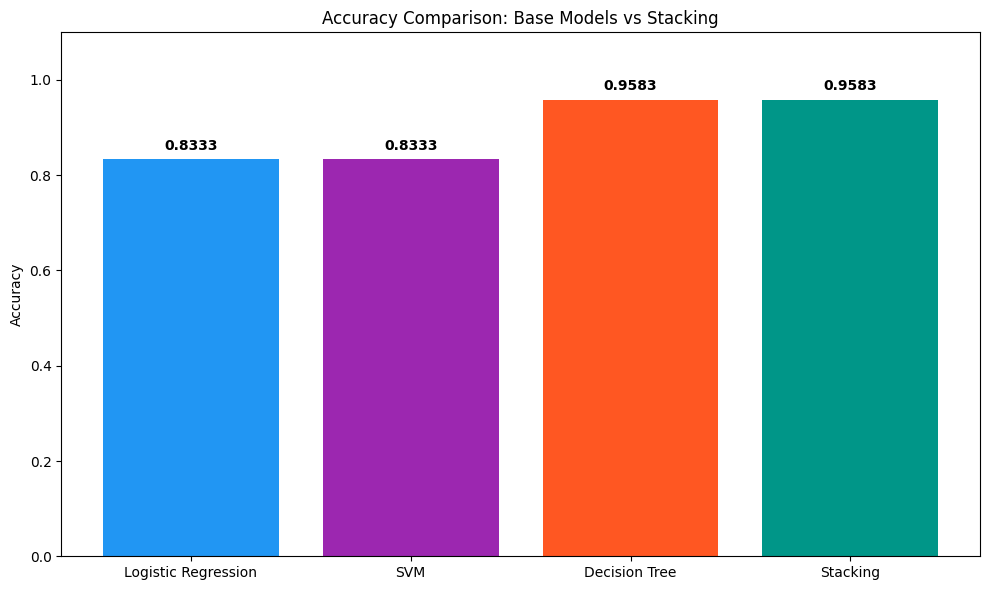

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

print("Name     : Priya Dharshini R")
print("Roll No  : 24BAD092")
print("Scenario : Stacking (Heart Disease Prediction)")

# Load dataset
df = pd.read_csv(r"/content/sample_data/heart_stacking.csv")

# Split data
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Base models
lr = LogisticRegression(random_state=42, max_iter=1000)
svm = SVC(probability=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

# Train base models
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

# Accuracy of base models
lr_acc = accuracy_score(y_test, lr.predict(X_test))
svm_acc = accuracy_score(y_test, svm.predict(X_test))
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Stacking model
estimators = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('svm', SVC(probability=True, random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(random_state=42)
)

stacking_clf.fit(X_train, y_train)
stack_acc = accuracy_score(y_test, stacking_clf.predict(X_test))

# Print results
print("Model Accuracy Results")
print(f"Logistic Regression Accuracy : {lr_acc:.4f}")
print(f"SVM Accuracy                : {svm_acc:.4f}")
print(f"Decision Tree Accuracy      : {dt_acc:.4f}")
print(f"Stacking Classifier Accuracy: {stack_acc:.4f}")

# Visualization with different colors
plt.figure(figsize=(10, 6))

models = ['Logistic Regression', 'SVM', 'Decision Tree', 'Stacking']
accuracies = [lr_acc, svm_acc, dt_acc, stack_acc]

bars = plt.bar(models, accuracies,
               color=['#2196F3', '#9C27B0', '#FF5722', '#009688'])

plt.title('Accuracy Comparison: Base Models vs Stacking')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02,
             f"{yval:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**SCENARIO 5** – SMOTE

**Problem Statement:**\
Detect fraudulent transactions.

**Dataset:** \
Credit Card Fraud Detection Dataset

**Target Variable:** \
Fraud (0 = Normal, 1 = Fraud)

**Input Features:**\
Transaction Amount, Time, PCA features

**IN-LAB TASKS**\
•	Check class imbalance\
•	Apply SMOTE\
•	Train model before & after SMOTE\
•	Compare performance

**Visualization**\
•	Class distribution (Before & After SMOTE)\
•	Precision-Recall Curve


Name     : Priya Dharshini R
Roll No  : 24BAD092
Scenario : SMOTE (Fraud Detection)
Class Distribution Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64

Class Distribution After SMOTE (Train Set):
 Fraud
1    88
0    88
Name: count, dtype: int64

Model Performance Comparison

Before SMOTE Classification Report:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24


After SMOTE Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.33      0.50      0.40         2

    accuracy                           0.88        24
   macro avg       0.64      0.70      0.67        24
weighted avg       0.90      0.88 

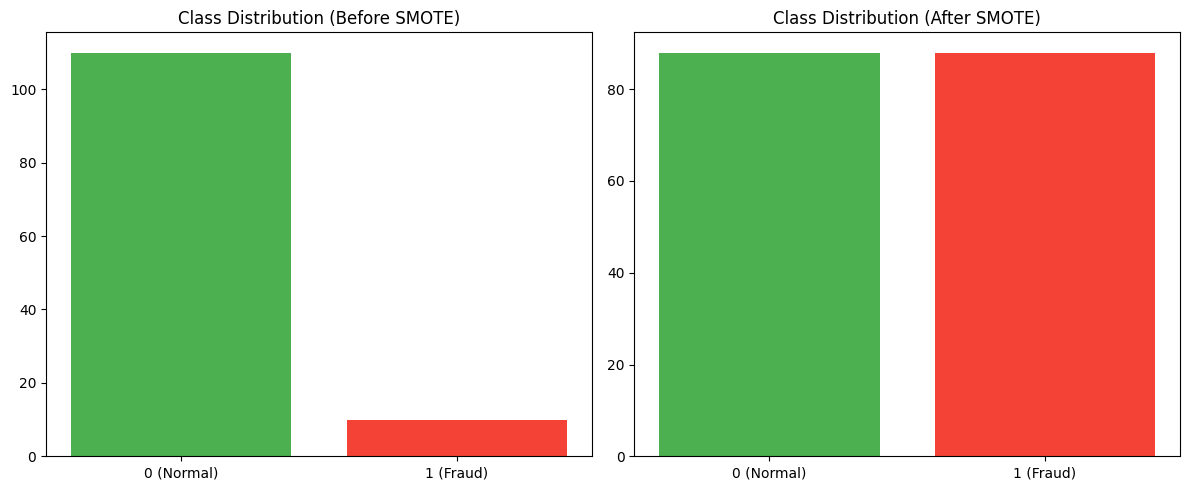

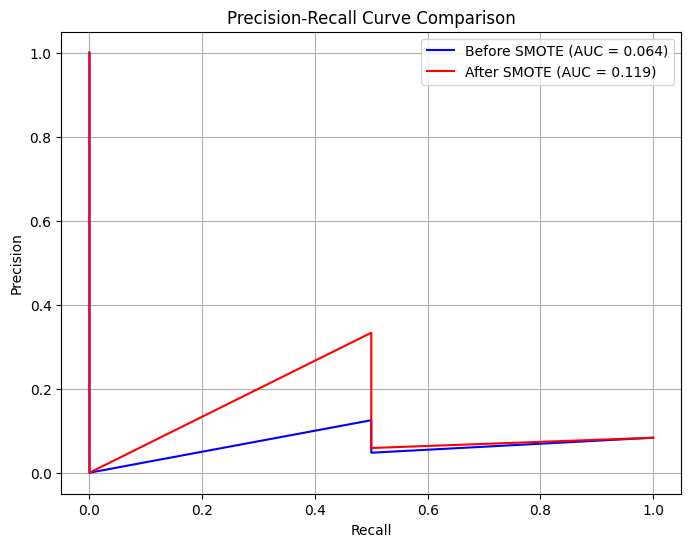

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')

# Print student details
print("Name     : Priya Dharshini R")
print("Roll No  : 24BAD092")
print("Scenario : SMOTE (Fraud Detection)")

# Custom SMOTE Class
class CustomSMOTE:
    def __init__(self, k_neighbors=5, random_state=None):
        self.k_neighbors = k_neighbors
        self.random_state = random_state
        if random_state is not None:
            np.random.seed(random_state)

    def fit_resample(self, X, y):
        # Save column names BEFORE converting
        columns = X.columns
        target_name = y.name

        X = np.array(X)
        y = np.array(y)

        classes, counts = np.unique(y, return_counts=True)
        majority_class = classes[np.argmax(counts)]
        minority_class = classes[np.argmin(counts)]

        N_majority, N_minority = max(counts), min(counts)
        N_synthetic = N_majority - N_minority

        X_minority = X[y == minority_class]

        nn = NearestNeighbors(n_neighbors=self.k_neighbors + 1)
        nn.fit(X_minority)

        synthetic_samples = []

        for _ in range(N_synthetic):
            idx = np.random.randint(0, N_minority)
            sample = X_minority[idx]

            distances, indices = nn.kneighbors([sample])
            neighbor_idx = np.random.choice(indices[0][1:])
            neighbor = X_minority[neighbor_idx]

            gap = np.random.rand()
            synthetic = sample + gap * (neighbor - sample)
            synthetic_samples.append(synthetic)

        X_resampled = np.vstack((X, np.array(synthetic_samples)))
        y_resampled = np.hstack((y, np.full(N_synthetic, minority_class)))

        # Use saved column names
        return pd.DataFrame(X_resampled, columns=columns), pd.Series(y_resampled, name=target_name)

# Load dataset
df = pd.read_csv(r"/content/sample_data/fraud_smote.csv")

# Check class imbalance
class_counts_before = df['Fraud'].value_counts()

X = df.drop('Fraud', axis=1)
y = df['Fraud']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Model BEFORE SMOTE
rf_before = RandomForestClassifier(random_state=42, n_estimators=50)
rf_before.fit(X_train, y_train)

y_pred_before = rf_before.predict(X_test)
y_prob_before = rf_before.predict_proba(X_test)[:, 1]

# Apply SMOTE
smote = CustomSMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

class_counts_after = y_train_smote.value_counts()

# Model AFTER SMOTE
rf_after = RandomForestClassifier(random_state=42, n_estimators=50)
rf_after.fit(X_train_smote, y_train_smote)

y_pred_after = rf_after.predict(X_test)
y_prob_after = rf_after.predict_proba(X_test)[:, 1]

# Print class distribution
print("Class Distribution Before SMOTE:\n", class_counts_before)
print("\nClass Distribution After SMOTE (Train Set):\n", class_counts_after)

# Performance comparison
print("\nModel Performance Comparison")

print("\nBefore SMOTE Classification Report:\n")
print(classification_report(y_test, y_pred_before))

print("\nAfter SMOTE Classification Report:\n")
print(classification_report(y_test, y_pred_after))

# Visualization: Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['0 (Normal)', '1 (Fraud)'], class_counts_before.values,
            color=['#4CAF50', '#F44336'])
axes[0].set_title('Class Distribution (Before SMOTE)')

axes[1].bar(['0 (Normal)', '1 (Fraud)'], class_counts_after.values,
            color=['#4CAF50', '#F44336'])
axes[1].set_title('Class Distribution (After SMOTE)')

plt.tight_layout()
plt.show()

# Precision-Recall Curve
precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
pr_auc_b = auc(recall_b, precision_b)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)
pr_auc_a = auc(recall_a, precision_a)

plt.figure(figsize=(8, 6))
plt.plot(recall_b, precision_b, color='blue',
         label=f'Before SMOTE (AUC = {pr_auc_b:.3f})')
plt.plot(recall_a, precision_a, color='red',
         label=f'After SMOTE (AUC = {pr_auc_a:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid()
plt.show()